Saving Dataset for internal CO2 corrosion of oil pipeline.xlsx to Dataset for internal CO2 corrosion of oil pipeline (1).xlsx
Original dataset shape: (243, 11)

Rows removed due to missing/non-numeric values: 0

CLEAN DATASET
Clean dataset: 243 rows × 8 columns

Column names:
['temperature_C', 'flow_velocity_ms', 'co2_pressure_bar', 'internal_pressure_bar', 'inhibitor_efficiency_pct', 'shear_stress_Pa', 'pH', 'corrosion_rate_mmyr']

Statistical summary:
       temperature_C  flow_velocity_ms  co2_pressure_bar  \
count        243.000           243.000           243.000   
mean          40.000             1.500             1.500   
std            8.182             0.245             0.409   
min           30.000             1.200             1.000   
25%           30.000             1.200             1.000   
50%           40.000             1.500             1.500   
75%           50.000             1.800             2.000   
max           50.000             1.800             2.000   

 

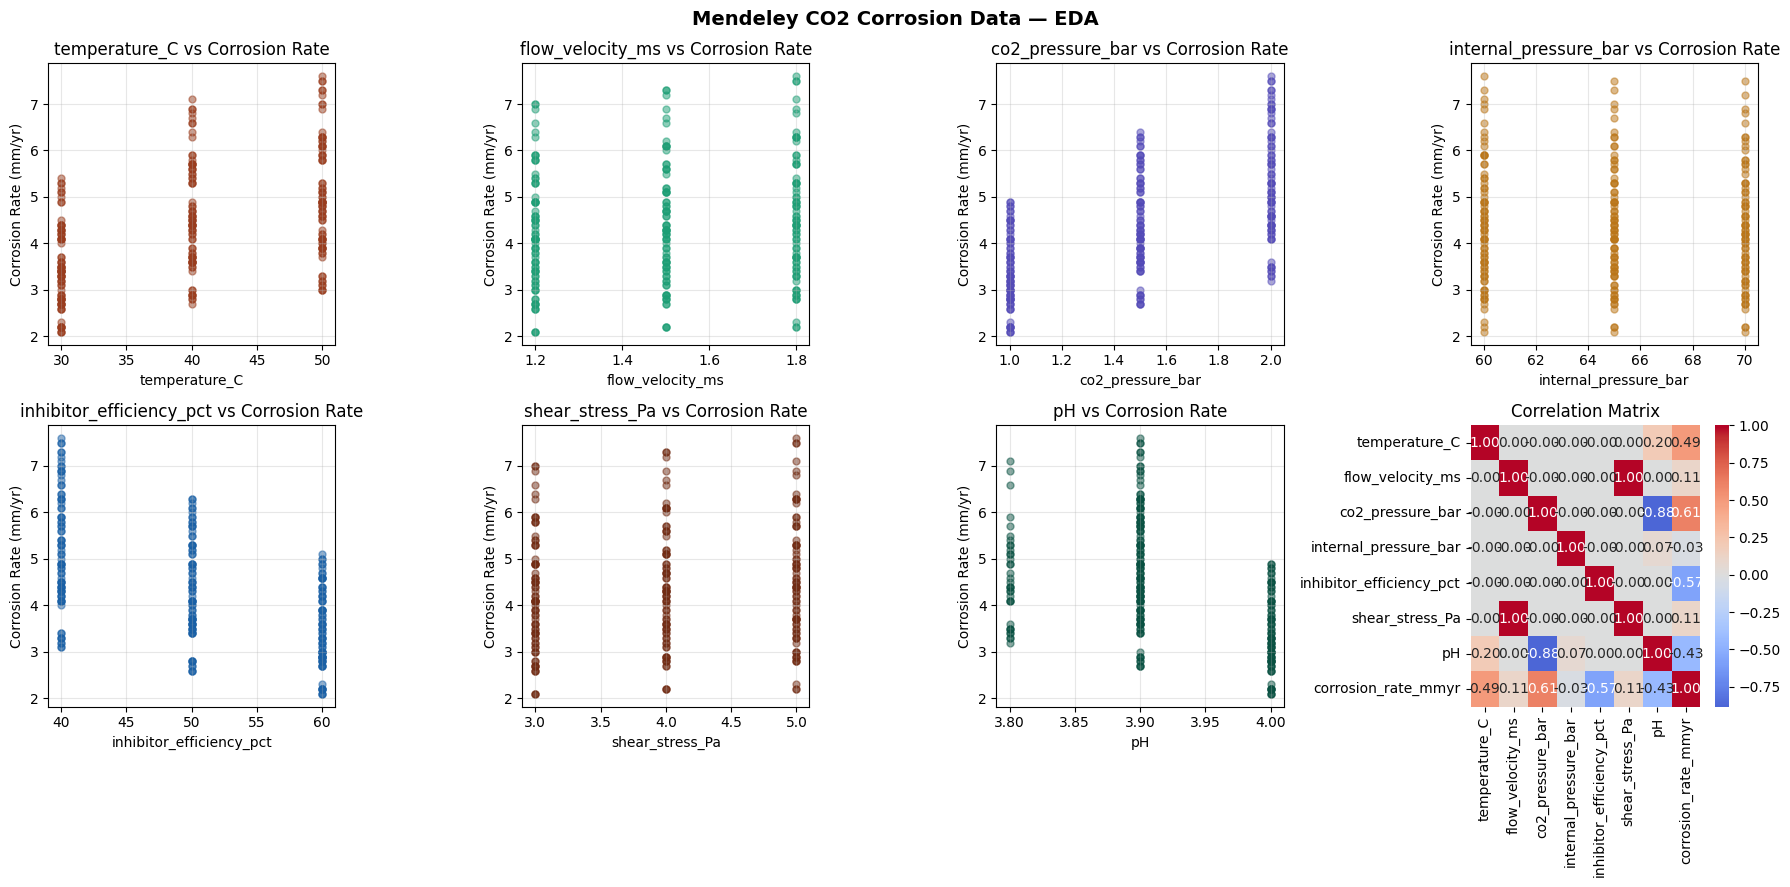


EDA complete ✓

TRAIN / TEST SPLIT
Training samples: 194
Testing samples:  49

MODEL PERFORMANCE
Model                  R²(log)    MAE(log)    R²(mm/y)    MAE(mm/y)     CV R²
------------------------------------------------------------------------------
XGBoost                 0.9952      0.0060      0.9956       0.0609    0.9953
RandomForest            0.9925      0.0077      0.9933       0.0764    0.9926
GradientBoosting        0.9955      0.0051      0.9967       0.0490    0.9974

ENSEMBLE PERFORMANCE
Ensemble R²:  0.9964
Ensemble MAE: 0.05524 mm/yr

Note: lower/upper values represent model disagreement, not a statistically validated confidence interval.

Models saved ✓


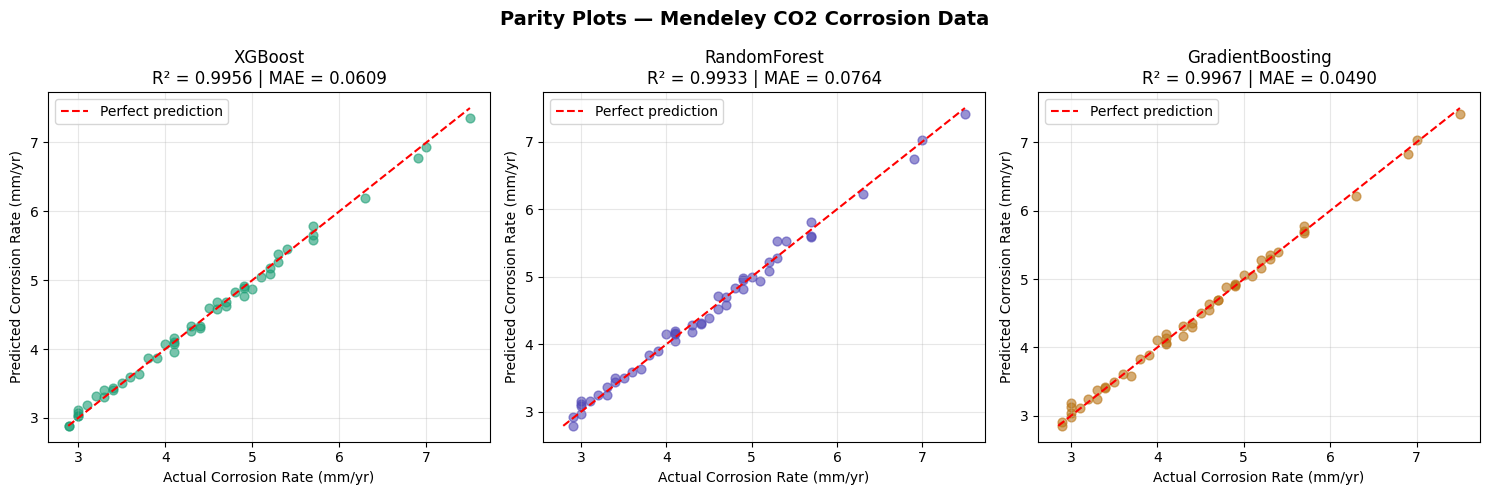

Parity plots saved ✓


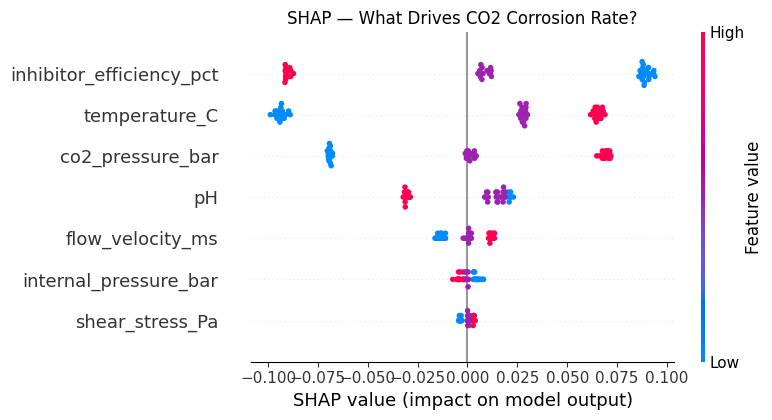

SHAP analysis complete ✓

PIPELINE CORROSION ASSESSMENT
Corrosion Rate: 5.08705 mm/yr
Model-disagreement range: 4.76214 – 5.43413 mm/yr
Estimated Remaining Life: 1.8 years
Shorter model-based estimate: 1.7 years
Longer model-based estimate: 1.9 years
Prototype Risk Category: Critical

IMPORTANT:
Remaining life assumes approximately constant corrosion rate.
Risk thresholds are prototype/user-defined unless validated against an engineering standard.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ALL FILES DOWNLOADED ✓

Next step:
Build Streamlit corrosion prediction dashboard.


In [ ]:


from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings("ignore")


uploaded = files.upload()

filename = list(uploaded.keys())[0]

df_raw = pd.read_excel(filename)

print("Original dataset shape:", df_raw.shape)
df = df_raw.drop(
    columns=["Unnamed: 8", "Unnamed: 9", "Unnamed: 10"],
    errors="ignore"
)
df.columns = [
    "temperature_C",
    "flow_velocity_ms",
    "co2_pressure_bar",
    "internal_pressure_bar",
    "inhibitor_efficiency_pct",
    "shear_stress_Pa",
    "pH",
    "corrosion_rate_mmyr"
]
df = df.apply(pd.to_numeric, errors="coerce")

before_nan = len(df)

df = df.dropna()

after_nan = len(df)

print(f"\nRows removed due to missing/non-numeric values: "
      f"{before_nan - after_nan}")

df = df[df["corrosion_rate_mmyr"] > 0]


df = df[df["pH"] > 0]

df = df[df["temperature_C"] > 0]

df = df.reset_index(drop=True)


print("\n========================================")
print("CLEAN DATASET")
print("========================================")

print(
    f"Clean dataset: "
    f"{df.shape[0]} rows × {df.shape[1]} columns"
)

print("\nColumn names:")
print(df.columns.tolist())

print("\nStatistical summary:")
print(df.describe().round(3))


feature_cols = [
    "temperature_C",
    "flow_velocity_ms",
    "co2_pressure_bar",
    "internal_pressure_bar",
    "inhibitor_efficiency_pct",
    "shear_stress_Pa",
    "pH"
]

target_col = "corrosion_rate_mmyr"

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes = axes.ravel()

colors = [
    "#993C1D",
    "#1D9E75",
    "#534AB7",
    "#BA7517",
    "#185FA5",
    "#712B13",
    "#085041"
]

for i, (col, color) in enumerate(
    zip(feature_cols, colors)
):

    axes[i].scatter(
        df[col],
        df[target_col],
        alpha=0.5,
        color=color,
        s=25
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Corrosion Rate (mm/yr)")
    axes[i].set_title(f"{col} vs Corrosion Rate")
    axes[i].grid(True, alpha=0.3)



sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[7]
)

axes[7].set_title("Correlation Matrix")


plt.suptitle(
    "Mendeley CO2 Corrosion Data — EDA",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "eda_mendeley.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nEDA complete ✓")


X = df[feature_cols].copy()

y = np.log10(df[target_col])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n========================================")
print("TRAIN / TEST SPLIT")
print("========================================")

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


models = {

    "XGBoost": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        verbosity=0
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )
}

trained_models = {}

print("\n========================================")
print("MODEL PERFORMANCE")
print("========================================")

print(
    f"{'Model':20s}"
    f"{'R²(log)':>10}"
    f"{'MAE(log)':>12}"
    f"{'R²(mm/y)':>12}"
    f"{'MAE(mm/y)':>13}"
    f"{'CV R²':>10}"
)

print("-" * 78)


for name, model in models.items():


    model.fit(
        X_train,
        y_train
    )

    y_pred_log = model.predict(X_test)

    actual_cr = 10 ** y_test.values

    predicted_cr = 10 ** y_pred_log


    r2_log = r2_score(
        y_test,
        y_pred_log
    )

    mae_log = mean_absolute_error(
        y_test,
        y_pred_log
    )


    r2_original = r2_score(
        actual_cr,
        predicted_cr
    )

    mae_original = mean_absolute_error(
        actual_cr,
        predicted_cr
    )



    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_mean = cv_scores.mean()


    print(
        f"{name:20s}"
        f"{r2_log:10.4f}"
        f"{mae_log:12.4f}"
        f"{r2_original:12.4f}"
        f"{mae_original:13.4f}"
        f"{cv_mean:10.4f}"
    )



    trained_models[name] = model



def ensemble_predict(X_input):

    """
    Predict corrosion rate using all trained models.

    Returns:
        mean prediction
        lower model-disagreement estimate
        upper model-disagreement estimate
    """

    predictions = np.array([
        model.predict(X_input)
        for model in trained_models.values()
    ])

    # Average prediction in log space
    mean_log = predictions.mean(axis=0)

    # Standard deviation between models
    std_log = predictions.std(axis=0)

    # Convert back to original corrosion-rate scale
    mean_cr = 10 ** mean_log

    lower_cr = 10 ** (mean_log - std_log)

    upper_cr = 10 ** (mean_log + std_log)

    return (
        mean_cr,
        lower_cr,
        upper_cr
    )



ensemble_mean, ensemble_low, ensemble_high = (
    ensemble_predict(X_test)
)


actual_test_cr = 10 ** y_test.values


ensemble_r2 = r2_score(
    actual_test_cr,
    ensemble_mean
)

ensemble_mae = mean_absolute_error(
    actual_test_cr,
    ensemble_mean
)


print("\n========================================")
print("ENSEMBLE PERFORMANCE")
print("========================================")

print(
    f"Ensemble R²:  {ensemble_r2:.4f}"
)

print(
    f"Ensemble MAE: {ensemble_mae:.5f} mm/yr"
)

print(
    "\nNote: lower/upper values represent "
    "model disagreement, not a statistically "
    "validated confidence interval."
)


joblib.dump(
    trained_models,
    "corrosion_models.pkl"
)

print("\nModels saved ✓")


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


model_names = list(
    trained_models.keys()
)


plot_colors = [
    "#1D9E75",
    "#534AB7",
    "#BA7517"
]


for i, (name, color) in enumerate(
    zip(model_names, plot_colors)
):

    model = trained_models[name]

    # Predict test data
    y_pred_log = model.predict(X_test)

    # Convert back to original scale
    actual = 10 ** y_test.values
    predicted = 10 ** y_pred_log

    # Calculate metrics
    r2 = r2_score(
        actual,
        predicted
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    # Scatter plot
    axes[i].scatter(
        actual,
        predicted,
        alpha=0.6,
        color=color,
        s=40
    )

    # Perfect prediction line
    mn = min(
        actual.min(),
        predicted.min()
    )

    mx = max(
        actual.max(),
        predicted.max()
    )

    axes[i].plot(
        [mn, mx],
        [mn, mx],
        "r--",
        lw=1.5,
        label="Perfect prediction"
    )

    axes[i].set_title(
        f"{name}\n"
        f"R² = {r2:.4f} | "
        f"MAE = {mae:.4f}"
    )

    axes[i].set_xlabel(
        "Actual Corrosion Rate (mm/yr)"
    )

    axes[i].set_ylabel(
        "Predicted Corrosion Rate (mm/yr)"
    )

    axes[i].legend()

    axes[i].grid(
        True,
        alpha=0.3
    )


plt.suptitle(
    "Parity Plots — Mendeley CO2 Corrosion Data",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "parity_plots.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Parity plots saved ✓")


!pip install shap -q

import shap


# Select XGBoost model
xgb_model = trained_models["XGBoost"]


# Create SHAP explainer
explainer = shap.TreeExplainer(
    xgb_model
)


# Calculate SHAP values
shap_values = explainer.shap_values(
    X_test
)


# SHAP summary plot
plt.figure(
    figsize=(10, 6)
)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_cols,
    show=False
)

plt.title(
    "SHAP — What Drives CO2 Corrosion Rate?"
)

plt.tight_layout()

plt.savefig(
    "shap_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("SHAP analysis complete ✓")


def predict_remaining_life(
    conditions,
    wall_thickness_mm=12.0,
    min_wall_mm=3.0
):

    """
    Estimate corrosion rate and simplified remaining life.

    conditions must contain:
    [temperature,
     flow velocity,
     CO2 pressure,
     internal pressure,
     inhibitor efficiency,
     shear stress,
     pH]
    """


    X_input = pd.DataFrame(
        [conditions],
        columns=feature_cols
    )


    cr_mean, cr_low, cr_high = (
        ensemble_predict(X_input)
    )

    cr = cr_mean[0]

    low_model_cr = cr_low[0]
    high_model_cr = cr_high[0]

    if cr <= 0:

        raise ValueError(
            "Predicted corrosion rate must be positive."
        )



    allowable_loss = (
        wall_thickness_mm -
        min_wall_mm
    )

    if allowable_loss <= 0:

        raise ValueError(
            "Wall thickness must be greater "
            "than minimum allowable thickness."
        )



    remaining_life = (
        allowable_loss / cr
    )



    worst_case_life = (
        allowable_loss / high_model_cr
    )

    best_case_life = (
        allowable_loss / low_model_cr
    )


    if cr < 0.1:

        risk = "Low"

    elif cr < 0.5:

        risk = "Medium"

    elif cr < 2.0:

        risk = "High"

    else:

        risk = "Critical"

    print("\n========================================")
    print("PIPELINE CORROSION ASSESSMENT")
    print("========================================")

    print(
        f"Corrosion Rate: "
        f"{cr:.5f} mm/yr"
    )

    print(
        f"Model-disagreement range: "
        f"{low_model_cr:.5f} – "
        f"{high_model_cr:.5f} mm/yr"
    )

    print(
        f"Estimated Remaining Life: "
        f"{remaining_life:.1f} years"
    )

    print(
        f"Shorter model-based estimate: "
        f"{worst_case_life:.1f} years"
    )

    print(
        f"Longer model-based estimate: "
        f"{best_case_life:.1f} years"
    )

    print(
        f"Prototype Risk Category: "
        f"{risk}"
    )

    print(
        "\nIMPORTANT:"
        "\nRemaining life assumes approximately "
        "constant corrosion rate."
        "\nRisk thresholds are prototype/user-defined "
        "unless validated against an engineering standard."
    )

    return (
        cr,
        remaining_life,
        risk
    )

sample = [
    60,     # Temperature °C
    2.0,    # Flow velocity m/s
    3.0,    # CO2 pressure bar
    80,     # Internal pressure bar
    50,     # Inhibitor efficiency %
    40,     # Shear stress Pa
    4.5     # pH
]


predict_remaining_life(
    sample,
    wall_thickness_mm=12.0,
    min_wall_mm=3.0
)


files.download(
    "corrosion_models.pkl"
)

files.download(
    "parity_plots.png"
)

files.download(
    "shap_summary.png"
)

files.download(
    "eda_mendeley.png"
)


print("\n========================================")
print("ALL FILES DOWNLOADED ✓")
print("========================================")

print("\nNext step:")
print("Build Streamlit corrosion prediction dashboard.")